In [276]:
import pandas as pd
import platform
import matplotlib.pyplot as plt

In [277]:
# csv 폴더 안에 card 폴더 안에 있는 오프라인.csv 파일 로드
offline = pd.read_csv('../csv/card/오프라인.csv', encoding='cp949')

In [278]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   object 
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [279]:
offline.head()

,crym,tco_btc_nm,ma_fem_dc,agegrp_dc,tco_btc_u_ct,tco_btc_u_am
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


1. 컬럼의 이름을 변경 -> 항목정의서의 컬럼의 설명을 기준으로 컬럼의 이름을 변경
2. 결측치가 존재하는가?
    - non-null count을 기준으로 확인
    - 성별 컬럼에는 '-', 9 라는 데이터가 존재하는가?
3. 기준년월의 데이터를 시계열 데이터로 변환
4. 남, 여 성별을 기준으로 연도별 건당 이용 금액의 평균을 어떠한 차이를 나타내는가?
    - 기준년월의 시계열이서 년도를 추출하여 새로운 컬럼에 대입
    - 건당 이용금액 컬럼을 생성하여 총이용금액 / 총건수
    - 성별, 기준년 컬럼의 데이터로 그룹화 건당이용 금액의 평균을 구한다.
5. 해당 데이터를 막대그래프로 시각화

In [280]:
# 항목정의서 파일을 로드
col_info = pd.read_excel(
    "../csv/card/(수정)(항목정의서)유통+업종+카드소비트랜드+데이터_20211101.xlsx"
)

In [281]:
col_info['데이터 컬럼']

0     기준년월
1    업종 구분
2       성별
3      연령대
4    이용 건수
5    이용 금액
Name: 데이터 컬럼, dtype: object

In [282]:
offline.columns = col_info['데이터 컬럼'].to_list()

In [283]:
offline.head()

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액
0,201901,백화점,1,1,1,7.600000e+03
1,201901,백화점,1,10,379,1.945872e+07
2,201901,백화점,1,20,45173,4.747711e+09
3,201901,백화점,1,30,271858,2.791826e+10
4,201901,백화점,1,40,391109,3.791149e+10


In [284]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   기준년월    2648 non-null   int64  
 1   업종 구분   2648 non-null   object 
 2   성별      2648 non-null   int64  
 3   연령대     2648 non-null   int64  
 4   이용 건수   2648 non-null   int64  
 5   이용 금액   2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [285]:
offline.columns = ['기준년월' ,'업종 구분', '성별', '연령대', '이용 건수', '이용 금액']

In [286]:
offline.isna().sum()

기준년월     0
업종 구분    0
성별       0
연령대      0
이용 건수    0
이용 금액    0
dtype: int64

In [287]:
# 성별 컬럼에 '-', 9 데이터가 존재하는가?
# offline['성별'].isin(['-', '9' ,9]).sum()
offline['성별'].isin(['-', '9' ,9]).any()
offline['성별'].isin([1, 2]).all()

np.True_

In [288]:
offline['성별'].value_counts()

성별
2    1336
1    1312
Name: count, dtype: int64

In [289]:
# 유일한 데이터를 출력
offline['성별'].unique()

array([1, 2])

In [290]:
# 기준년월 데이터를 시계열로 변경
pd.to_datetime(offline['기준년월'], format = '%Y%m')

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[ns]

In [291]:
from datetime import datetime

In [292]:
offline['기준년월']

0       201901
1       201901
2       201901
3       201901
4       201901
         ...  
2643    202109
2644    202109
2645    202109
2646    202109
2647    202109
Name: 기준년월, Length: 2648, dtype: int64

In [293]:
offline['기준년월'].map(
    lambda x : datetime.strptime(str(x), '%Y%m')
)

0      2019-01-01
1      2019-01-01
2      2019-01-01
3      2019-01-01
4      2019-01-01
          ...    
2643   2021-09-01
2644   2021-09-01
2645   2021-09-01
2646   2021-09-01
2647   2021-09-01
Name: 기준년월, Length: 2648, dtype: datetime64[ns]

In [294]:
offline['기준년월'] = offline['기준년월'].astype(str).map(
    lambda x : datetime.strptime(x, '%Y%m')
)

In [295]:
# 기준년이라는 컬럼을 생성해서 기준년월에서 년도만 추출하여 대입
offline['기준년'] = offline['기준년월'].dt.strftime('%Y')

In [296]:
offline['기준년월'].dt.year

0       2019
1       2019
2       2019
3       2019
4       2019
        ... 
2643    2021
2644    2021
2645    2021
2646    2021
2647    2021
Name: 기준년월, Length: 2648, dtype: int32

In [297]:
offline

,기준년월,업종 구분,성별,연령대,이용 건수,이용 금액,기준년
0,2019-01-01,백화점,1,1,1,7.600000e+03,2019
1,2019-01-01,백화점,1,10,379,1.945872e+07,2019
2,2019-01-01,백화점,1,20,45173,4.747711e+09,2019
3,2019-01-01,백화점,1,30,271858,2.791826e+10,2019
4,2019-01-01,백화점,1,40,391109,3.791149e+10,2019
...,...,...,...,...,...,...,...
2643,2021-09-01,편의점,2,50,844081,6.283353e+09,2021
2644,2021-09-01,편의점,2,60,243768,1.997442e+09,2021
2645,2021-09-01,편의점,2,70,40523,3.524203e+08,2021
2646,2021-09-01,편의점,2,80,6349,5.333488e+07,2021


In [298]:
# 건당이용금액
offline['건당이용금액'] = (offline['이용 금액'] / offline['이용 건수']).round(2)

In [299]:
# 성별, 기준년을 이용하여 그룹화
group_data = offline.groupby(['기준년','성별'])['건당이용금액'].mean()

In [300]:
# 그래프에서 한글 깨짐 방지
if platform.system() == 'Darwin':
    plt.rc('font', family = 'AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')

<Axes: xlabel='기준년,성별'>

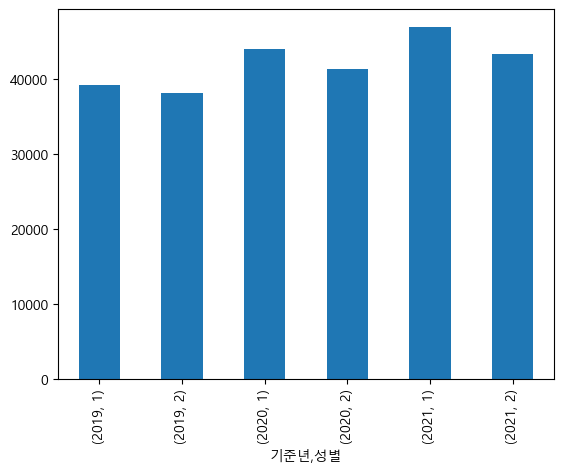

In [301]:
group_data.plot(kind = 'bar')

In [302]:
group_data.unstack()

성별,1,2
기준년,,
2019,39184.349663,38107.838727
2020,44009.589560,41389.763077
2021,46948.320222,43306.318944


<Axes: xlabel='기준년'>

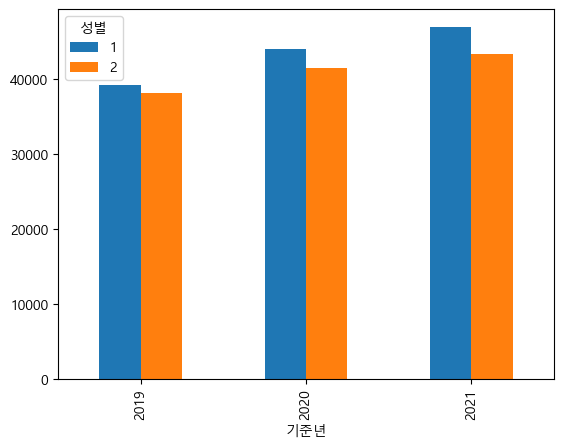

In [303]:
group_data.unstack().plot(kind = 'bar')


<Axes: xlabel='기준년'>

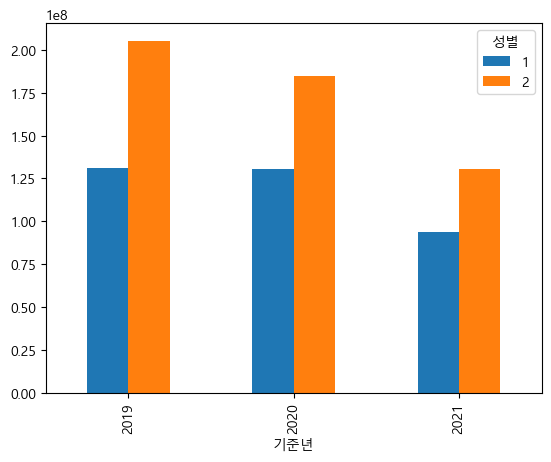

In [304]:
# 년도, 성별 이용 건수와 합계를 확인
offline.pivot_table(
    index = '기준년',
    columns = '성별',
    values = '이용 건수',
    aggfunc = 'sum'
).plot(kind='bar')

<Axes: xlabel='기준년월'>

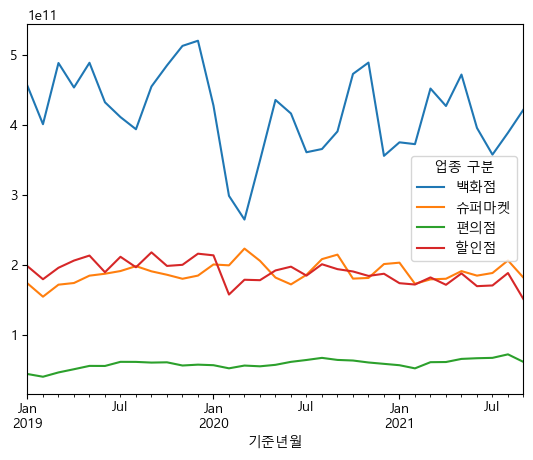

In [305]:

offline.pivot_table(
    index = '기준년월',
    columns = '업종 구분',
    values = '이용 금액',
    aggfunc = 'sum'
).plot()

In [306]:
offline['연령대'].value_counts()

연령대
10    264
20    264
30    264
70    264
40    264
50    264
60    264
90    264
80    264
0     233
1      39
Name: count, dtype: int64

In [307]:
# 업종, 연령대 별로 월별 이용금액의 합계, 총 이용건수

group_data2 = offline.pivot_table(
    index = '기준년',
    columns = ['업종 구분', '연령대'],
    values = ['이용 건수', '이용 금액'],
    aggfunc = 'sum',
    fill_value = 0
)

In [308]:
df1 = group_data2['이용 건수']

In [309]:
df2 = group_data2['이용 금액']

<Axes: xlabel='연령대'>

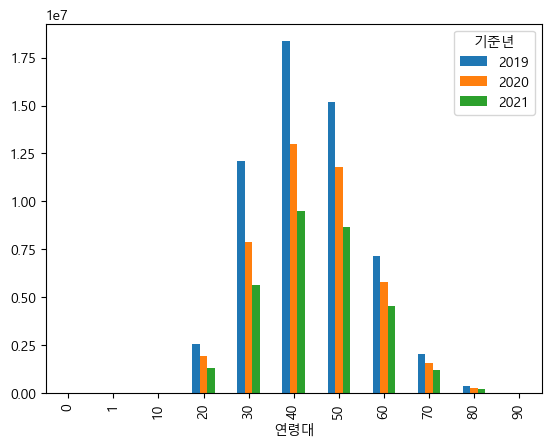

In [310]:
df1['백화점'].T.plot(kind='bar')

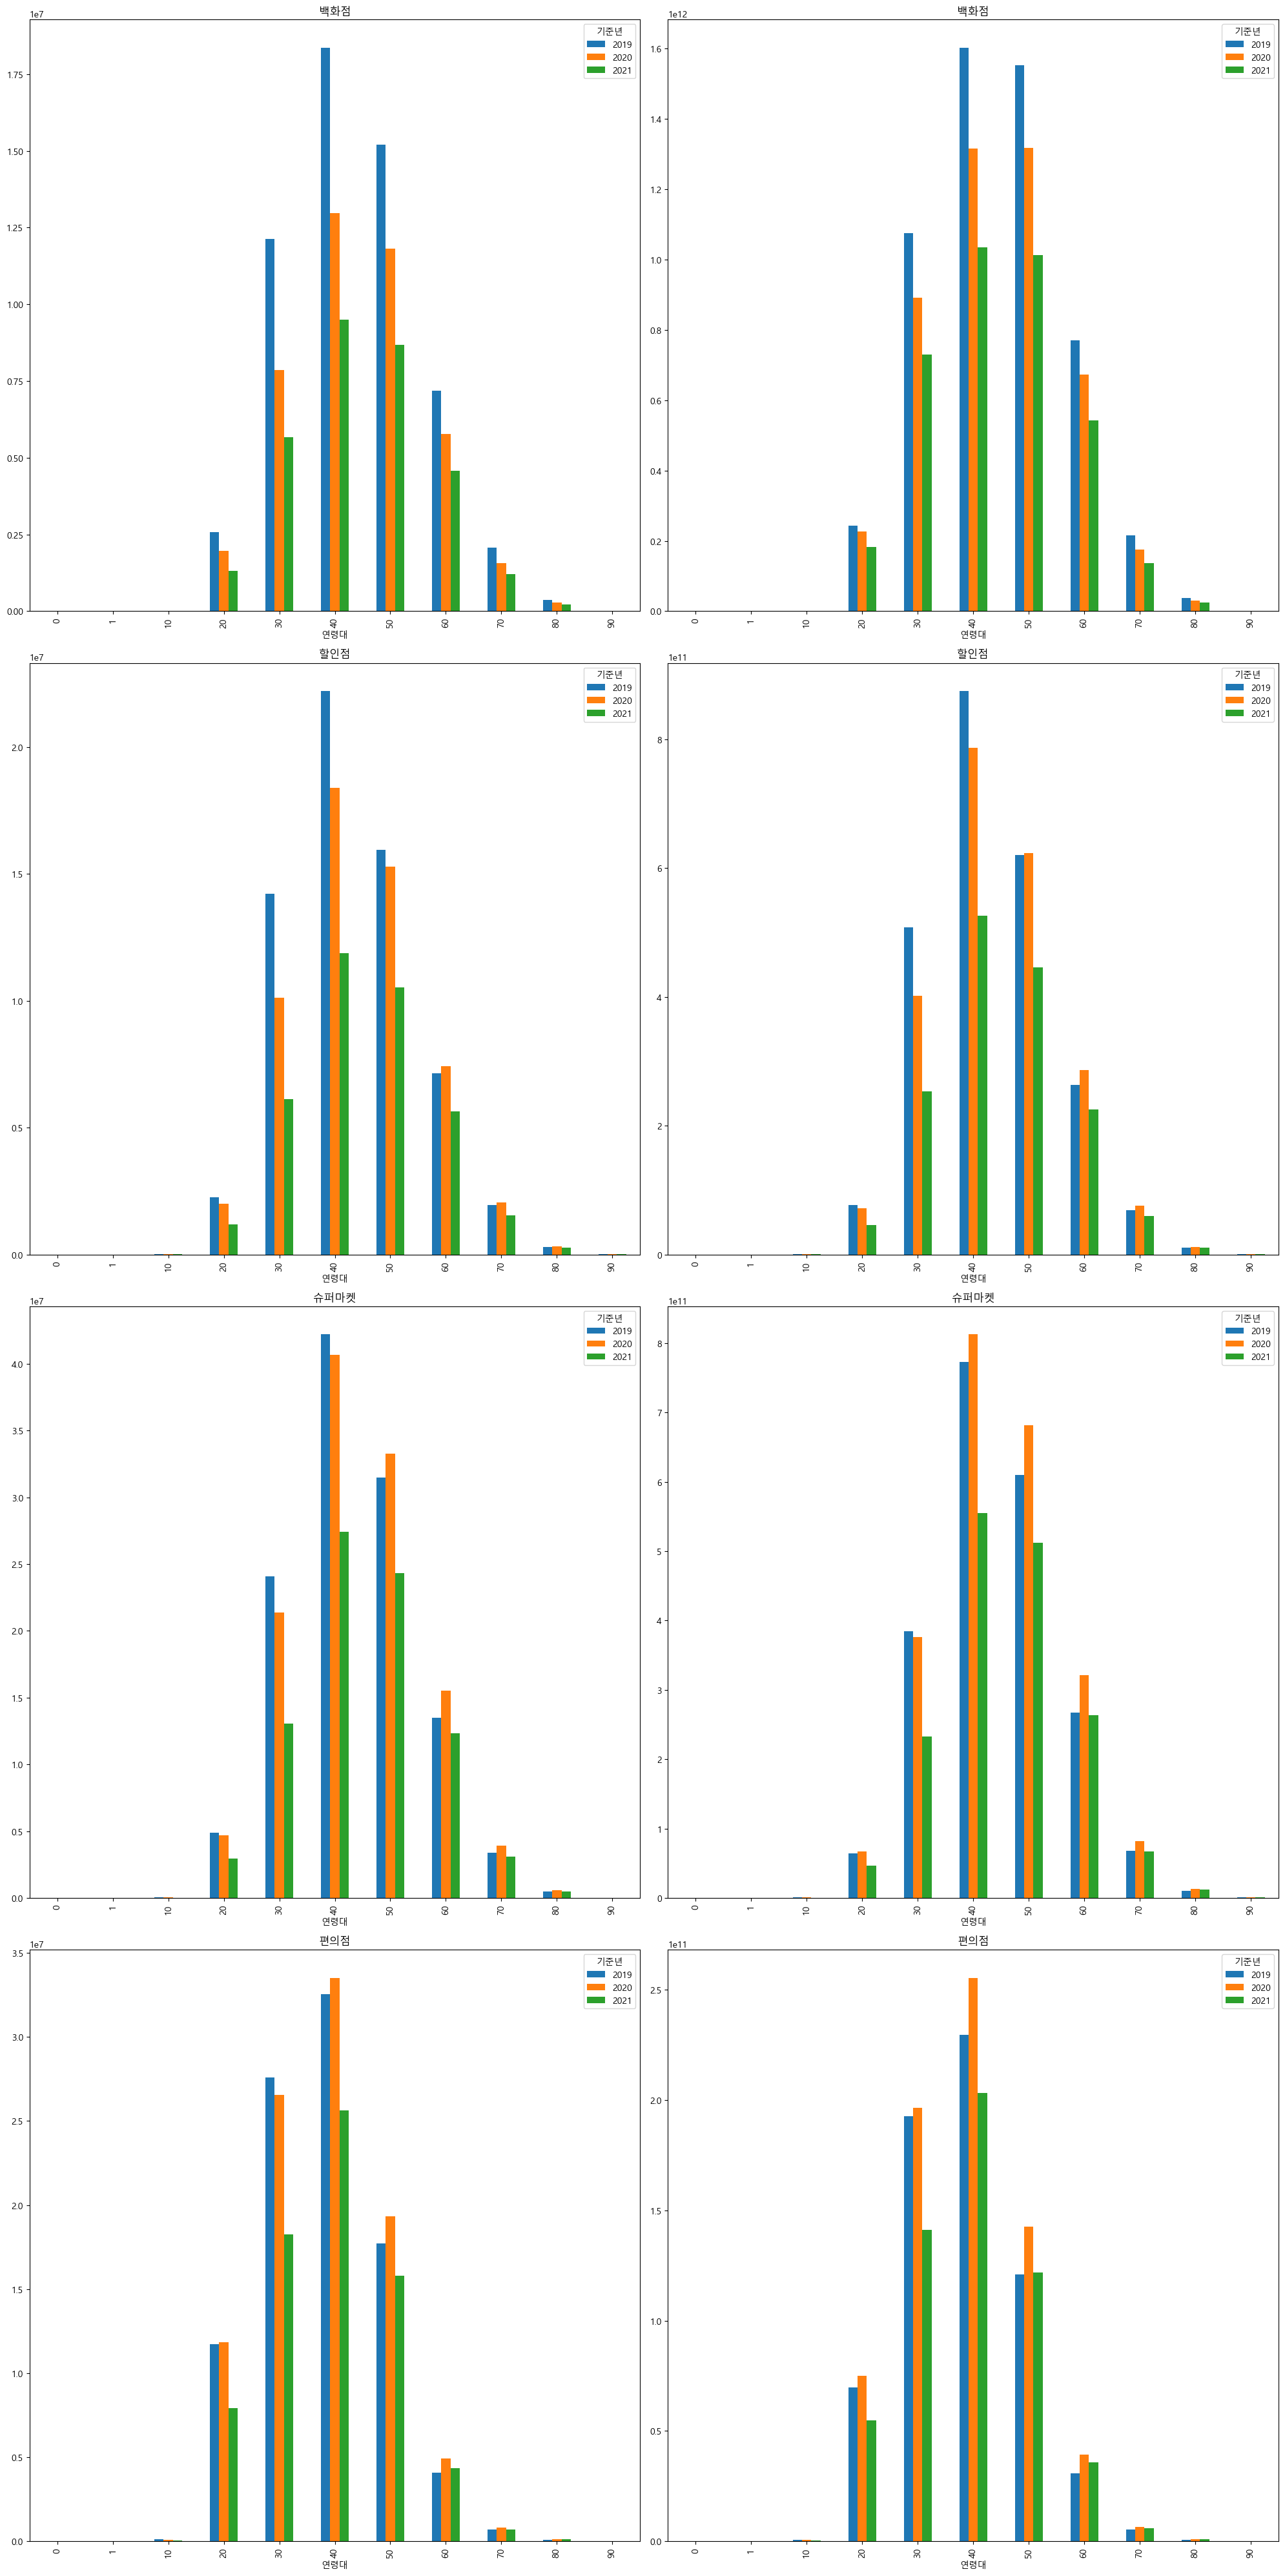

In [311]:
# 8(4*2)개의 공간을 생성하고 반복 실행할때 행이 1씩 증가하는 위치에 그래프 그린다.
plt.figure(figsize = (20, 40))
# 업종의 수만큼 반복 실행
_list = offline['업종 구분'].unique()
for i in range(len(_list)):
    ax1 = plt.subplot(4, 2, 2*i+1)
    # df1의 특정 컬럼을 선택하고 전치하여 막대그래프로 표시
    df1[_list[i]].T.plot(kind='bar', ax = ax1)
    # 그래프의 이름은 해당 컬럼의 이름으로 지정
    plt.title(_list[i])
    ax2 = plt.subplot(4, 2, 2*(i+1))
    df2[_list[i]].T.plot(kind='bar', ax = ax2)
    plt.title(_list[i])

plt.tight_layout()    
plt.show()

In [312]:
offline = pd.read_csv("../csv/card/오프라인.csv", encoding='cp949')

In [313]:
online = pd.read_csv("../csv/card/온라인.csv")

In [314]:
offline.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2648 entries, 0 to 2647
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   crym          2648 non-null   int64  
 1   tco_btc_nm    2648 non-null   object 
 2   ma_fem_dc     2648 non-null   int64  
 3   agegrp_dc     2648 non-null   int64  
 4   tco_btc_u_ct  2648 non-null   int64  
 5   tco_btc_u_am  2648 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 124.3+ KB


In [315]:
online.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651 entries, 0 to 650
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   crym          651 non-null    int64
 1   ma_fem_dc     651 non-null    int64
 2   agegrp_dc     651 non-null    int64
 3   tco_btc_u_ct  651 non-null    int64
 4   tco_btc_u_am  651 non-null    int64
dtypes: int64(5)
memory usage: 25.6 KB


In [316]:
# offline 컬럼의 이름을 변경
offline.columns = ['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액']
# online 컬럼의 이름을 변경
online.columns = ['기준년월', '성별', '연령대', '이용건수', '이용금액']

In [317]:
# offline과 online 데이터프레임의 구조를 동일하게 만들기 위해 online의 '업종' 컬럼을 추가
online['업종'] = '온라인'

In [318]:
print(offline.columns)
print(online.columns)

Index(['기준년월', '업종', '성별', '연령대', '이용건수', '이용금액'], dtype='object')
Index(['기준년월', '성별', '연령대', '이용건수', '이용금액', '업종'], dtype='object')


In [319]:
df = pd.concat(
    [online, offline],
    axis = 'index',
    ignore_index = True
)

In [320]:
df

,기준년월,성별,연령대,이용건수,이용금액,업종
0,201901,1,1,1,1.106850e+05,온라인
1,201901,1,10,2333,9.810822e+07,온라인
2,201901,1,20,272915,1.385408e+10,온라인
3,201901,1,30,1320227,8.294613e+10,온라인
4,201901,1,40,1372052,9.555085e+10,온라인
...,...,...,...,...,...,...
3294,202109,2,50,844081,6.283353e+09,편의점
3295,202109,2,60,243768,1.997442e+09,편의점
3296,202109,2,70,40523,3.524203e+08,편의점
3297,202109,2,80,6349,5.333488e+07,편의점


<Axes: xlabel='기준년월'>

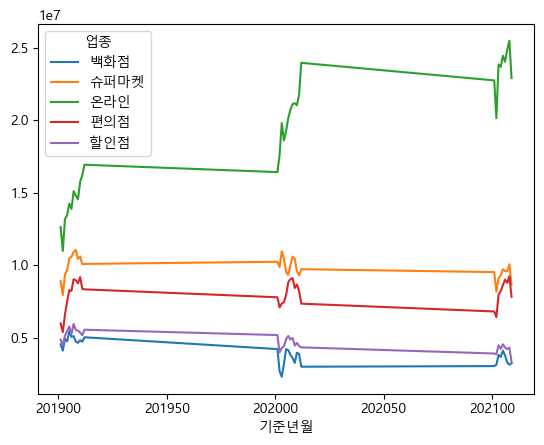

In [321]:
# 업종, 기준년월 별 총 이용건수의 그래프 시각화
df.pivot_table(
    index = '기준년월',
    columns = '업종',
    values = '이용건수',
    aggfunc = 'sum'
).plot()

In [322]:
# 그래프로 시각화를 기준년월을 x축으로 지정을 하니 숫자형으로 인식하여 그래프 간격에 문제가 발생
# 기준년월을 시게열 데이터로 변경
df['기준년월'] = pd.to_datetime(df['기준년월'], format = '%Y%m')

<Axes: xlabel='기준년월'>

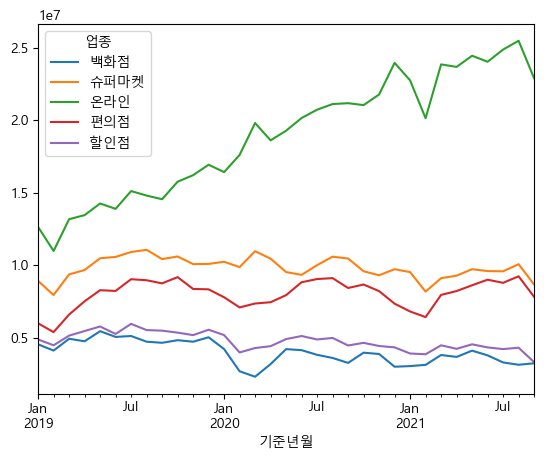

In [323]:
df.pivot_table(
    index = '기준년월',
    columns = '업종',
    values = '이용건수',
    aggfunc = 'sum'
).plot()

- 온라인, 오프라인을 기준으로 총이용건수, 총이용금액을 그래프로 시각화하여 출력
    - 파생변수 온/오프 생성하여 업종의 데이터의 값이 온라인이라면 0, 그 외의 조건이라며 1

In [324]:
# case1 : 반복문을 이용
# 반복횟수는 df의 길이만큼, 업종 컬럼의 value가 온라인인가?
# 빈 리스트에 반복할때마다 0, 1을 추가
# 만들어진 리스트를 새로운 파생변수에 추가
_list = []
# 위치를 기준으로 반복문 생성
for i in range(len(df)):
    # i에 대입이 되는 데이터는 ? -> df의 index의 위치
    # 조건식 사용
    if df.iloc[i, -1] == '온라인':
        _list.append(0)
    else:
        _list.append(1)
_list

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [325]:
_list = []
# 1차원 데이터(Series)를 기준으로 반복문을 생성
for name in df['업종']:
    # name에 대입되는 데이터는 ? -> Series에 Value가 하나씩 대입
    if name == '온라인':
        _list.append(0)
    else:
        _list.append(1)
_list

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [326]:
# while문으로 반복 실행

_list2 = []
# 초기값
i = 0
while i < len(df):
    if df['업종'].iloc[i] == '온라인':
        _list2.append(0)
    else:
        _list2.append(1)
    i += 1
_list2

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [327]:
_list == _list2

True

In [328]:
df['on/off'] = _list

<Axes: xlabel='기준년월'>

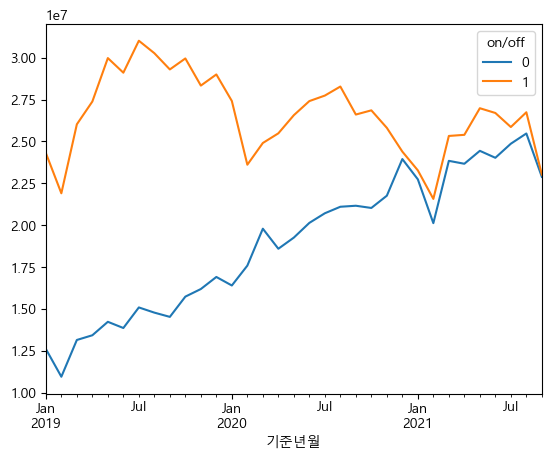

In [333]:
df.pivot_table(
    index = '기준년월',
    columns = 'on/off',
    values = '이용건수',
    aggfunc = 'sum'
).plot()

In [336]:
# on/off2 컬럼을 생성하여 map() 데이터를 추가
# lambda에서 if문을 한줄로 표현
# '참인 경우 데이터' if 조건식 else '거짓인 경우 데이터'
df['on/off2'] = df['업종'].map(
    lambda x : 0 if x == '온라인' else 1
)

In [339]:
(df['on/off'] == df['on/off2']).all()

np.True_

In [346]:
# 파생변수를 미리 생성하여 기본값을 설정
df['on/off3'] = 1

flag = df['업종'] == '온라인'
df.loc[flag, 'on/off3'] = 0

In [351]:
df.loc[ : , 'on/off' : 'on/off3'].sum(axis=1).value_counts()

3    2648
0     651
Name: count, dtype: int64

<Axes: xlabel='기준년월'>

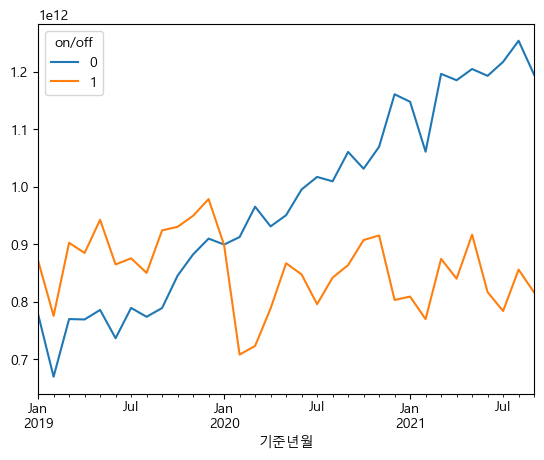

In [352]:
df.pivot_table(
    index = '기준년월',
    columns = 'on/off',
    values = '이용금액',
    aggfunc = 'sum'
).plot()

<Axes: xlabel='기준년월'>

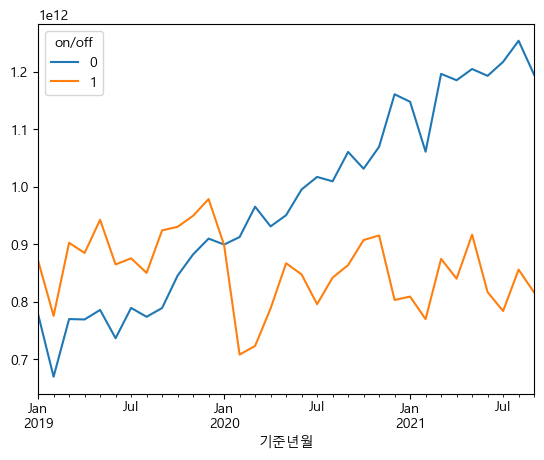

In [358]:
# groupby 함수를 이용해서 위와 같은 그래프를 생성
df.groupby(['기준년월', 'on/off'])['이용금액'].sum().unstack().plot()